In [1]:
# import packages
import os
import pyproj
from glob import glob
import geopandas as gpd
from pathlib import Path
from typing import List, Union
import numpy as np
import matplotlib.pyplot as plt
import rioxarray
import xarray as xr
import rasterio as rio
import pandas as pd
import seaborn as sns
from rasterio.enums import Resampling
from scipy.ndimage import gaussian_filter
sns.set_theme()

## set up

In [2]:
# set up paths, directories, and variables for this specific dam
data_path = '/home/jovyan/repos/fufiters_imja_analysis/data'
asc_burst = '012_023790_IW1'
des_burst = '121_258661_IW2'
asc_burst_path = f'{data_path}/data_igrams/{asc_burst}'
des_burst_path = f'{data_path}/data_igrams/{des_burst}'

dam_name = 'imja'
proc_path = f'/home/jovyan/repos/fufiters_imja_analysis/analysis'

# define crs 
crs = 32645

In [3]:
# read in dam polygon
dam_fn = f'../../mapping/polygons/{dam_name}_md.shp'
dam_gdf = gpd.read_file(dam_fn)
dam_gdf = dam_gdf.to_crs(crs) # reproject in case of mistake

# load in moving area polygon
moving_fn = f'../../mapping/polygons/{dam_name}_moving.shp'
moving_gdf = gpd.read_file(moving_fn)

# load in moving area polygon
reference_fn = f'../../mapping/polygons/{dam_name}_reference.shp'
reference_gdf = gpd.read_file(reference_fn)

# load in stable area polygon
stable_fn = f'../../mapping/polygons/{dam_name}_stable.shp'
stable_gdf = gpd.read_file(stable_fn).to_crs(crs)

# load in water mask
water_fn = f'../../mapping/polygons/imjalake_poly_20150130.gpkg'
water_gdf = gpd.read_file(water_fn).to_crs(crs)

# pad dam bounds by 5 km 
padding = 5000
aoi_extent = [dam_gdf.bounds.minx.item()-padding,
               dam_gdf.bounds.maxy.item()+padding,
               dam_gdf.bounds.maxx.item()+padding,
               dam_gdf.bounds.miny.item()-padding]

# load in dem products

In [4]:
# open DEM diff map
dem_vz_fn = '../dem_analysis/products_v1/dem_vz.tif'
dem_vz_ds = rioxarray.open_rasterio(dem_vz_fn).squeeze()
dem_vz_ds = dem_vz_ds.where(dem_vz_ds != -9999.)
dem_vz_ds = dem_vz_ds.rio.write_nodata(np.nan)

# open dem ew map
dem_vx_fn = '../dem_analysis/products_v1/dem_vx.tif'
dem_vx_ds = rioxarray.open_rasterio(dem_vx_fn).squeeze()
dem_vx_ds = dem_vx_ds.where(dem_vx_ds != -9999.)
dem_vx_ds = dem_vx_ds.rio.write_nodata(np.nan)

# open dem ns map
dem_vy_fn = '../dem_analysis/products_v1/dem_vy.tif'
dem_vy_ds = rioxarray.open_rasterio(dem_vy_fn).squeeze()
dem_vy_ds = dem_vy_ds.where(dem_vy_ds != -9999.)
dem_vy_ds = dem_vy_ds.rio.write_nodata(np.nan)

In [5]:
# mask with water mask
vz_mask = rio.features.geometry_mask([water_gdf.union_all()],
                                       out_shape=(len(dem_vz_ds.y), len(dem_vz_ds.x)),
                                       transform=dem_vz_ds.rio.transform())
vz_mask = xr.DataArray(vz_mask , dims=("y", "x"))

vx_mask = rio.features.geometry_mask([water_gdf.union_all()],
                                       out_shape=(len(dem_vx_ds.y), len(dem_vx_ds.x)),
                                       transform=dem_vx_ds.rio.transform())
vx_mask = xr.DataArray(vx_mask, dims=("y", "x"))

vy_mask = rio.features.geometry_mask([water_gdf.union_all()],
                                       out_shape=(len(dem_vy_ds.y), len(dem_vy_ds.x)),
                                       transform=dem_vy_ds.rio.transform())
vy_mask = xr.DataArray(vy_mask, dims=("y", "x"))

dem_vz_ds = dem_vz_ds.where(vz_mask == True)
dem_vx_ds = dem_vx_ds.where(vx_mask == True)
dem_vy_ds = dem_vy_ds.where(vy_mask == True)

In [6]:
# resample to fufiters grid
# open InSAR vertical velocity
fufiters_vud_fn = '../vertical_velocity.tif'
fufiters_vud_da = rioxarray.open_rasterio(fufiters_vud_fn).squeeze()

# mask water
fufiters_mask = rio.features.geometry_mask([water_gdf.union_all()],
                                       out_shape=(len(fufiters_vud_da.y), len(fufiters_vud_da.x)),
                                       transform=fufiters_vud_da.rio.transform())
fufiters_mask = xr.DataArray(fufiters_mask, dims=("y", "x"))

fufiters_vud_da = fufiters_vud_da.where(fufiters_mask)

# open min summer coherence
min_summer_coherence_fn = '../min_summer_coherence.tif'
min_summer_coherence = rioxarray.open_rasterio(min_summer_coherence_fn).squeeze().rio.write_crs(crs)

dem_vz_ds = dem_vz_ds.rio.reproject_match(min_summer_coherence, resampling=Resampling.med)
dem_vx_ds = dem_vx_ds.rio.reproject_match(min_summer_coherence, resampling=Resampling.med)
dem_vy_ds = dem_vy_ds.rio.reproject_match(min_summer_coherence, resampling=Resampling.med)

# dem_vz_ds = dem_vz_ds.rio.reproject_match(fufiters_vud_da, resampling=Resampling.med)
# dem_vx_ds = dem_vx_ds.rio.reproject_match(fufiters_vud_da, resampling=Resampling.med)
# dem_vy_ds = dem_vy_ds.rio.reproject_match(fufiters_vud_da, resampling=Resampling.med)

In [7]:
# mask 
corr_thresh = 0.7
dem_vz_ds = dem_vz_ds.where(min_summer_coherence >= corr_thresh)
dem_vx_ds = dem_vx_ds.where(min_summer_coherence >= corr_thresh)
dem_vy_ds = dem_vy_ds.where(min_summer_coherence >= corr_thresh)

# # coarsen to fufiters resolution
# factor=6
# dem_vz_ds = dem_vz_ds.coarsen(x = factor, boundary = 'trim').median().coarsen(y = factor, boundary = 'trim').median()
# dem_vx_ds = dem_vx_ds.coarsen(x = factor, boundary = 'trim').median().coarsen(y = factor, boundary = 'trim').median()
# dem_vy_ds = dem_vy_ds.coarsen(x = factor, boundary = 'trim').median().coarsen(y = factor, boundary = 'trim').median()

In [8]:
%%time
from scipy.ndimage import convolve

# Function to create a Gaussian kernel
def gaussian_kernel(size: int, sigma: float):
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)  # Normalize

kernel_size = 7
kernel_std = 3

# Generate the Gaussian kernel
dem_vz_kernel = gaussian_kernel(kernel_size, kernel_std).astype(np.float32)
dem_vxy_kernel = gaussian_kernel(kernel_size, kernel_std).astype(np.float32)

# Handle NaNs: create a mask (1 where valid, 0 where NaN)
dem_vz_mask = np.isnan(dem_vz_ds)
dem_vx_mask = np.isnan(dem_vx_ds)
dem_vy_mask = np.isnan(dem_vy_ds)
dem_vz_filled = np.where(dem_vz_mask, 0, dem_vz_ds)
dem_vx_filled = np.where(dem_vx_mask, 0, dem_vx_ds)
dem_vy_filled = np.where(dem_vy_mask, 0, dem_vy_ds)# Replace NaNs with 0 for convolution

# Convolve both image and mask
print('working on dem_vz')
dem_vz_smoothed = convolve(dem_vz_filled, dem_vz_kernel, mode='constant', cval=0)
print('working on dem_vx')
dem_vx_smoothed = convolve(dem_vx_filled, dem_vxy_kernel, mode='constant', cval=0)
print('working on dem_vy')
dem_vy_smoothed = convolve(dem_vy_filled, dem_vxy_kernel, mode='constant', cval=0)
print('working on dem_vz mask')
dem_vz_mask_convolved = convolve((~dem_vz_mask).astype(np.float32).values, dem_vz_kernel, mode='constant', cval=0)
print('working on dem_vx mask')
dem_vx_mask_convolved = convolve((~dem_vx_mask).astype(np.float32).values, dem_vxy_kernel, mode='constant', cval=0)
print('working on dem_vy mask')
dem_vy_mask_convolved = convolve((~dem_vy_mask).astype(np.float32).values, dem_vxy_kernel, mode='constant', cval=0)

# Normalize to avoid NaN-influenced blur
dem_vz_smoothed /= np.where(dem_vz_mask_convolved == 0, 1, dem_vz_mask_convolved)  # Avoid division by zero
dem_vx_smoothed /= np.where(dem_vx_mask_convolved == 0, 1, dem_vx_mask_convolved)  # Avoid division by zero
dem_vy_smoothed /= np.where(dem_vy_mask_convolved == 0, 1, dem_vy_mask_convolved)  # Avoid division by zero

# Convert back to xarray DataArray
dem_vz_ds = xr.DataArray(
    dem_vz_smoothed, dims=dem_vz_ds.dims, coords=dem_vz_ds.coords
)
# Convert back to xarray DataArray
dem_vx_ds = xr.DataArray(
    dem_vx_smoothed, dims=dem_vx_ds.dims, coords=dem_vx_ds.coords
)
# Convert back to xarray DataArray
dem_vy_ds = xr.DataArray(
    dem_vy_smoothed, dims=dem_vx_ds.dims, coords=dem_vy_ds.coords
)

working on dem_vz
working on dem_vx
working on dem_vy
working on dem_vz mask
working on dem_vx mask
working on dem_vy mask
CPU times: user 87.4 ms, sys: 0 ns, total: 87.4 ms
Wall time: 85.8 ms


In [60]:
# from scipy.ndimage import convolve

# # Function to create a Gaussian kernel with different sizes for x and y
# def gaussian_kernel(size_x: int, sigma_x: float, size_y: int, sigma_y: float):
#     ax = np.linspace(-(size_x // 2), size_x // 2, size_x)
#     ay = np.linspace(-(size_y // 2), size_y // 2, size_y)
#     xx, yy = np.meshgrid(ax, ay)
#     kernel = np.exp(-(xx**2 / (2 * sigma_x**2) + yy**2 / (2 * sigma_y**2)))
#     return kernel / np.sum(kernel)  # Normalize

# # Define kernel size and sigma for x and y directions
# kernel_size_x = 12
# kernel_size_y = 7  # Different size for y direction
# kernel_std_x = 6
# kernel_std_y = 3  # Different std deviation for y direction

# # Generate the Gaussian kernel with different sizes in x and y
# dem_vz_kernel = gaussian_kernel(kernel_size_x, kernel_std_x, kernel_size_y, kernel_std_y).astype(np.float32)
# dem_vxy_kernel = gaussian_kernel(kernel_size_x, kernel_std_x, kernel_size_y, kernel_std_y).astype(np.float32)

# # Handle NaNs: create a mask (1 where valid, 0 where NaN)
# dem_vz_mask = np.isnan(dem_vz_ds)
# dem_vx_mask = np.isnan(dem_vx_ds)
# dem_vy_mask = np.isnan(dem_vy_ds)
# dem_vz_filled = np.where(dem_vz_mask, 0, dem_vz_ds)
# dem_vx_filled = np.where(dem_vx_mask, 0, dem_vx_ds)
# dem_vy_filled = np.where(dem_vy_mask, 0, dem_vy_ds)  # Replace NaNs with 0 for convolution

# # Convolve both image and mask
# print('working on dem_vz')
# dem_vz_smoothed = convolve(dem_vz_filled, dem_vz_kernel, mode='constant', cval=0)
# print('working on dem_vx')
# dem_vx_smoothed = convolve(dem_vx_filled, dem_vxy_kernel, mode='constant', cval=0)
# print('working on dem_vy')
# dem_vy_smoothed = convolve(dem_vy_filled, dem_vxy_kernel, mode='constant', cval=0)
# print('working on dem_vz mask')
# dem_vz_mask_convolved = convolve((~dem_vz_mask).astype(np.float32).values, dem_vz_kernel, mode='constant', cval=0)
# print('working on dem_vx mask')
# dem_vx_mask_convolved = convolve((~dem_vx_mask).astype(np.float32).values, dem_vxy_kernel, mode='constant', cval=0)
# print('working on dem_vy mask')
# dem_vy_mask_convolved = convolve((~dem_vy_mask).astype(np.float32).values, dem_vxy_kernel, mode='constant', cval=0)

# # Normalize to avoid NaN-influenced blur
# dem_vz_smoothed /= np.where(dem_vz_mask_convolved == 0, 1, dem_vz_mask_convolved)  # Avoid division by zero
# dem_vx_smoothed /= np.where(dem_vx_mask_convolved == 0, 1, dem_vx_mask_convolved)  # Avoid division by zero
# dem_vy_smoothed /= np.where(dem_vy_mask_convolved == 0, 1, dem_vy_mask_convolved)  # Avoid division by zero

# # Convert back to xarray DataArray
# dem_vz_ds = xr.DataArray(
#     dem_vz_smoothed, dims=dem_vz_ds.dims, coords=dem_vz_ds.coords
# )
# # Convert back to xarray DataArray
# dem_vx_ds = xr.DataArray(
#     dem_vx_smoothed, dims=dem_vx_ds.dims, coords=dem_vz_ds.coords
# )
# # Convert back to xarray DataArray
# dem_vy_ds = xr.DataArray(
#     dem_vy_smoothed, dims=dem_vx_ds.dims, coords=dem_vy_ds.coords
# )


working on dem_vz
working on dem_vx
working on dem_vy
working on dem_vz mask
working on dem_vx mask
working on dem_vy mask


In [9]:
# resample again to fufiters grid spacing
dem_vz_ds = dem_vz_ds.rio.reproject_match(fufiters_vud_da, resampling=Resampling.bilinear)
dem_vx_ds = dem_vx_ds.rio.reproject_match(fufiters_vud_da, resampling=Resampling.bilinear)
dem_vy_ds = dem_vy_ds.rio.reproject_match(fufiters_vud_da, resampling=Resampling.bilinear)

# # save reasampled DEMs 
# dem_vz_ds.rio.to_raster('dem_vz_resampled.tif')
# dem_vx_ds.rio.to_raster('dem_vx_resampled.tif')
# dem_vy_ds.rio.to_raster('dem_vy_resampled.tif')

dem_vz_ds = dem_vz_ds.where(fufiters_mask == True)
dem_vx_ds = dem_vx_ds.where(fufiters_mask == True)
dem_vy_ds = dem_vy_ds.where(fufiters_mask == True)

In [12]:
dem_vz_ds.rio.to_raster('dem_vz_resampled.tif')
dem_vx_ds.rio.to_raster('dem_vx_resampled.tif')
dem_vy_ds.rio.to_raster('dem_vy_resampled.tif')

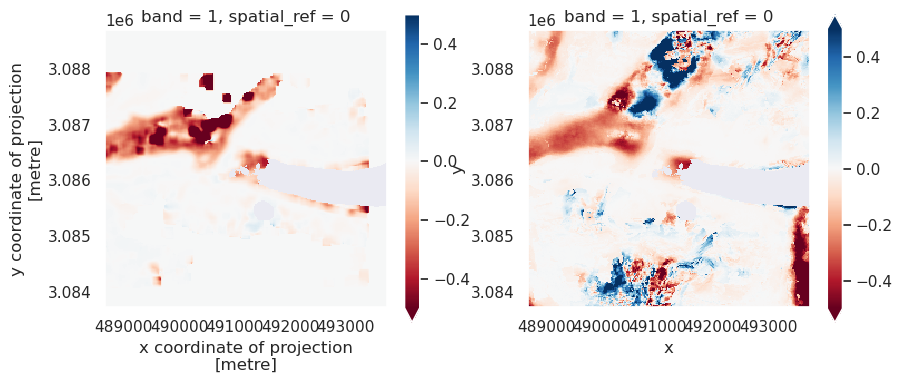

In [10]:
f, ax = plt.subplots(1, 2, figsize=(10, 4))
#(min_summer_coherence > 0.7).plot(ax=ax)
dem_vz_ds.plot(ax=ax[0], vmin=-0.5, vmax=0.5, cmap='RdBu')
(-fufiters_vud_da).plot(ax=ax[1], vmin=-0.5, vmax=0.5, cmap='RdBu')
ax[0].set_xlim(aoi_extent[0]+3000, aoi_extent[2]-3000)
ax[0].set_ylim(aoi_extent[3]+3000, aoi_extent[1]-3000)
ax[0].set_aspect('equal')
ax[1].set_xlim(aoi_extent[0]+3000, aoi_extent[2]-3000)
ax[1].set_ylim(aoi_extent[3]+3000, aoi_extent[1]-3000)
ax[1].set_aspect('equal')

## vertical comparison

In [13]:
# clip to moving area
fufiters_vud_moving = fufiters_vud_da.rio.clip(dam_gdf.geometry, crs=dam_gdf.crs, drop=True)
dem_vz_moving = dem_vz_ds.rio.clip(dam_gdf.geometry, crs=dam_gdf.crs, drop=True)

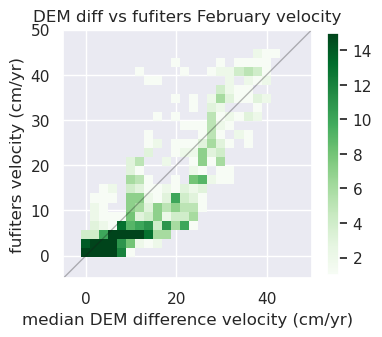

In [64]:
f, ax = plt.subplots(1, 1, figsize=(4, 4))
sns.histplot(ax=ax, x=(dem_vz_moving.values.ravel()*-100), y=(fufiters_vud_moving.values.ravel()*100), 
                 cmap='Greens', cbar=True, alpha=1, binwidth=2, vmin=None, vmax=15, cbar_kws={'shrink':0.7})
# sns.scatterplot(ax=ax, x=(dem_vz_moving.values.ravel()*-100), y=(fufiters_vud_moving.values.ravel()*100), size=2)
ax.plot([-200, 200], [-200, 200], color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.set_title('DEM diff vs fufiters February velocity')
ax.set_ylabel('fufiters velocity (cm/yr)')
ax.set_xlabel('median DEM difference velocity (cm/yr)')
ax.set_box_aspect(1)
ax.set_xlim(-5, 50)
ax.set_ylim(-5, 50)
ax.set_xticks([0, 20,40,])
f.tight_layout()

In [14]:
def calculate_r_squared(data1: xr.DataArray, data2: xr.DataArray) -> float:
    """
    Calculate the R-squared value between two 2D xarray DataArrays.

    Parameters:
    - data1 (xr.DataArray): The first 2D DataArray.
    - data2 (xr.DataArray): The second 2D DataArray.

    Returns:
    - float: The R-squared value.
    """
    
    # Flatten the data and remove NaN values
    data1_flat = data1.values.flatten()
    data2_flat = data2.values.flatten()
    
    # Mask out NaN values
    valid_mask = ~np.isnan(data1_flat) & ~np.isnan(data2_flat)
    data1_clean = data1_flat[valid_mask]
    data2_clean = data2_flat[valid_mask]
    
    # Check for sufficient data points
    if len(data1_clean) < 2 or len(data2_clean) < 2:
        raise ValueError("Insufficient valid data points to calculate R-squared.")
    
    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(data1_clean, data2_clean)
    r_squared = correlation_matrix[0, 1] ** 2
    
    return r_squared

In [16]:
calculate_r_squared(dem_vz_moving, fufiters_vud_moving)

0.7833157507927838

In [17]:
insar_only_vz_fn = '../vertical_velocity_imja_insaronly.tif'
insar_only_vz_da = xr.open_dataset(insar_only_vz_fn).squeeze().band_data
insar_only_vz_moving = insar_only_vz_da.rio.clip(dam_gdf.geometry, crs=dam_gdf.crs, drop=True)
insar_only_vz_moving = insar_only_vz_moving.rio.reproject_match(dem_vz_moving, resampling=Resampling.bilinear)

offset_only_vz_fn = '../vertical_velocity_imja_offsetsonly.tif'
offset_only_vz_da = xr.open_dataset(offset_only_vz_fn).squeeze().band_data
offset_only_vz_moving = offset_only_vz_da.rio.clip(dam_gdf.geometry, crs=dam_gdf.crs, drop=True)
offset_only_vz_moving = offset_only_vz_moving.rio.reproject_match(dem_vz_moving, resampling=Resampling.bilinear)

In [65]:
calculate_r_squared(dem_vz_moving, offset_only_vz_moving)

0.6725614371863875

In [19]:
calculate_r_squared(dem_vz_moving, offset_only_vz_moving)

0.6725614371863875

In [20]:
def nmad(da):
    """Compute the Normalized Median Absolute Deviation (NMAD) of an xarray DataArray."""
    med = np.nanmedian(da)  # Compute median, ignoring NaNs
    abs_dev = np.abs(da - med)  # Absolute deviations from median
    return 1.4826 * np.nanmedian(abs_dev)  # Scale by NMAD factor

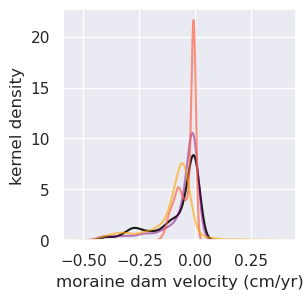

In [24]:
f, ax = plt.subplots(figsize=(3, 3))
sns.kdeplot(dem_vz_moving.values.ravel(), c='k')
sns.kdeplot(-fufiters_vud_moving.values.ravel(), c='purple', alpha=0.5)
sns.kdeplot(insar_only_vz_moving.values.ravel(), c='tomato', alpha=0.7)
sns.kdeplot(-offset_only_vz_moving.values.ravel(), c='orange', alpha=0.6)
ax.set_ylabel('kernel density')
ax.set_xlabel('moraine dam velocity (cm/yr)')
plt.savefig('../figs/moraine_vud_kdeplot.png', dpi=300, bbox_inches='tight')

## ew comparison

In [25]:
fufiters_vew_fn = '../ew_velocity.tif'
fufiters_vew_da = rioxarray.open_rasterio(fufiters_vew_fn).squeeze()

In [26]:
# clip to moving area
fufiters_vew_moving = fufiters_vew_da.rio.clip(dam_gdf.geometry, crs=dam_gdf.crs, drop=True)
dem_vx_moving = dem_vx_ds.rio.clip(dam_gdf.geometry, crs=dam_gdf.crs, drop=True)

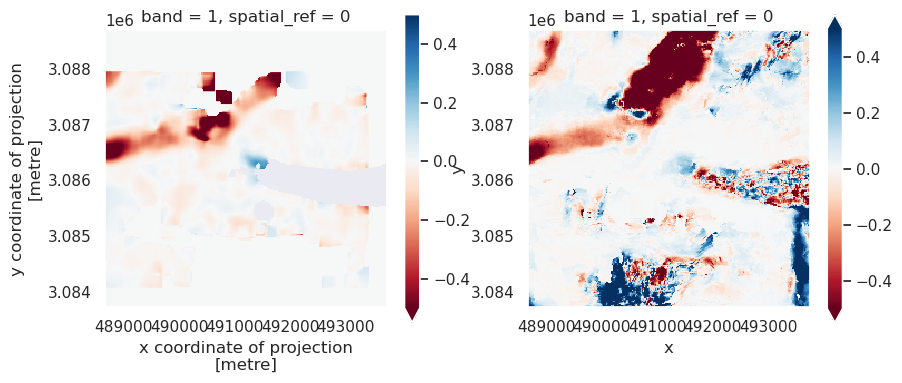

In [44]:
f, ax = plt.subplots(1, 2, figsize=(10, 4))
#(min_summer_coherence > 0.7).plot(ax=ax)
dem_vx_ds.plot(ax=ax[0], vmin=-0.5, vmax=0.5, cmap='RdBu')
fufiters_vew_da.plot(ax=ax[1], vmin=-0.5, vmax=0.5, cmap='RdBu')
#insar_only_vx_da.plot(ax=ax[1], vmin=-0.5, vmax=0.5, cmap='RdBu')
ax[0].set_xlim(aoi_extent[0]+3000, aoi_extent[2]-3000)
ax[0].set_ylim(aoi_extent[3]+3000, aoi_extent[1]-3000)
ax[0].set_aspect('equal')
ax[1].set_xlim(aoi_extent[0]+3000, aoi_extent[2]-3000)
ax[1].set_ylim(aoi_extent[3]+3000, aoi_extent[1]-3000)
ax[1].set_aspect('equal')

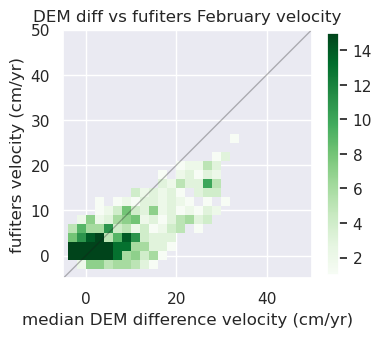

In [45]:
f, ax = plt.subplots(1, 1, figsize=(4, 4))
sns.histplot(ax=ax, x=(dem_vx_moving.values.ravel()*100), y=(fufiters_vew_moving.values.ravel()*100), 
                 cmap='Greens', cbar=True, alpha=1, binwidth=2, vmin=None, vmax=15, cbar_kws={'shrink':0.7})
# sns.scatterplot(ax=ax, x=(dem_vz_moving.values.ravel()*-100), y=(fufiters_vud_moving.values.ravel()*100), size=2)
ax.plot([-200, 200], [-200, 200], color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.set_title('DEM diff vs fufiters February velocity')
ax.set_ylabel('fufiters velocity (cm/yr)')
ax.set_xlabel('median DEM difference velocity (cm/yr)')
ax.set_box_aspect(1)
ax.set_xlim(-5, 50)
ax.set_ylim(-5, 50)
ax.set_xticks([0, 20,40,])
f.tight_layout()

In [27]:
calculate_r_squared(dem_vx_moving, fufiters_vew_moving)

0.5752759781147145

In [28]:
insar_only_vx_fn = '../ew_velocity_imja_insaronly.tif'
insar_only_vx_da = xr.open_dataset(insar_only_vx_fn).squeeze().band_data
insar_only_vx_moving = insar_only_vx_da.rio.clip(dam_gdf.geometry, crs=moving_gdf.crs, drop=True)
insar_only_vx_moving = insar_only_vx_moving.rio.reproject_match(dem_vx_moving, resampling=Resampling.bilinear)

offset_only_vx_fn = '../ew_velocity_imja_offsetsonly.tif'
offset_only_vx_da = xr.open_dataset(offset_only_vx_fn).squeeze().band_data
offset_only_vx_moving = offset_only_vx_da.rio.clip(dam_gdf.geometry, crs=moving_gdf.crs, drop=True)
offset_only_vx_moving = offset_only_vx_moving.rio.reproject_match(dem_vx_moving, resampling=Resampling.bilinear)

In [31]:
calculate_r_squared(dem_vx_moving, offset_only_vx_moving)

0.3535274399141592

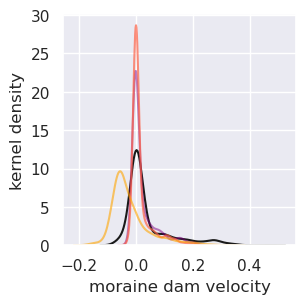

In [32]:
f, ax = plt.subplots(figsize=(3, 3))
sns.kdeplot(dem_vx_moving.values.ravel(), c='k')
sns.kdeplot(fufiters_vew_moving.values.ravel(), c='purple', alpha=0.5)
sns.kdeplot(insar_only_vx_moving.values.ravel(), c='tomato', alpha=0.7)
sns.kdeplot(-offset_only_vx_moving.values.ravel(), c='orange', alpha=0.6)
ax.set_ylabel('kernel density')
ax.set_xlabel('moraine dam velocity')
plt.savefig('../figs/moraine_vew_kdeplot.png', dpi=300, bbox_inches='tight')

In [55]:
calculate_r_squared(dem_vx_moving, fufiters_vew_moving)

0.5752759781147145